# BigBasket Category Performance Diagnostic — Pandas Validation

Independent Part 4 cleaning and cross-validation of the deliberately messy raw export. Missing revenue values are not filled and are excluded from revenue calculations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Raw shape:", orders.shape)
orders.info()
print("\nRaw describe:")
display(orders.describe(include="all"))
print("\nStatus counts:")
print(orders["status"].value_counts())
print("Duplicate order_id rows:", orders["order_id"].duplicated().sum())
print("Missing amount_inr:", orders["amount_inr"].isna().sum())
print("Raw cities:", sorted(orders["city"].unique()))
print("Raw categories:", sorted(orders["category"].unique()))
print("Largest amounts:", orders["amount_inr"].nlargest(10).tolist())


Raw shape: (508, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB

Raw describe:


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000



Status counts:
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64
Duplicate order_id rows: 8
Missing amount_inr: 10
Raw cities: [' Bengaluru ', ' Hyderabad ', ' Mumbai ', ' Pune ', 'BENGALURU', 'Bengaluru', 'HYDERABAD', 'Hyderabad', 'MUMBAI', 'Mumbai', 'PUNE', 'Pune', 'bengaluru', 'mumbai']
Raw categories: [' Bakery ', ' Dairy & Eggs ', ' Fruits & Vegetables ', ' Household Essentials ', ' Personal Care ', 'BAKERY', 'Bakery', 'DAIRY & EGGS', 'Dairy & Eggs', 'FRUITS & VEGETABLES', 'Fruits & Vegetables', 'HOUSEHOLD ESSENTIALS', 'Household Essentials', 'Personal Care', 'SNACKS & BEVERAGES', 'Snacks & Beverages', 'dairy & eggs', 'snacks & beverages']
Largest amounts: [7600.0, 5400.0, 5200.0, 4800.0, 4400.0, 1100.0, 900.0, 720.0, 720.0, 660.0]


## Cleaning and derived fields

In [2]:
df = orders.drop_duplicates(subset="order_id", keep="first").copy()
assert len(df) == 500

df["amount_inr"] = pd.to_numeric(df["amount_inr"], errors="coerce")
df["city"] = df["city"].str.strip().str.title()
df["category"] = df["category"].str.strip().str.title()

assert set(df["city"].unique()) == {"Bengaluru", "Mumbai", "Hyderabad", "Pune"}
assert set(df["category"].unique()) == {"Fruits & Vegetables", "Dairy & Eggs", "Snacks & Beverages", "Personal Care", "Household Essentials", "Bakery"}

df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["month_name"] = df["order_date"].dt.month_name()
df["is_delivered"] = df["status"].eq("Delivered")

delivered_amount = df.loc[df["is_delivered"] & df["amount_inr"].notna(), "amount_inr"]
q1 = delivered_amount.quantile(0.25)
q3 = delivered_amount.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr

df["amount_capped"] = df["amount_inr"].clip(upper=upper_fence)
df["revenue_per_unit"] = df["amount_capped"] / df["quantity"]
capped_count = int((delivered_amount > upper_fence).sum())

print("Rows after duplicate removal:", len(df))
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper fence:", upper_fence)
print("Delivered values capped:", capped_count)
print("Missing amounts retained:", int(df["amount_inr"].isna().sum()))


Rows after duplicate removal: 500
Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5
Delivered values capped: 16
Missing amounts retained: 10


## Revenue validation and cross-check

In [3]:
delivered = df[df["is_delivered"] & df["amount_capped"].notna()].copy()

category_revenue = (delivered.groupby("category", as_index=False)["amount_capped"].sum().rename(columns={"amount_capped":"delivered_revenue"}).sort_values("delivered_revenue", ascending=False))
supplier_df = delivered.merge(products[["product_id","supplier"]], on="product_id", how="left")
supplier_revenue = (supplier_df.groupby("supplier", as_index=False)["amount_capped"].sum().rename(columns={"amount_capped":"delivered_revenue"}).sort_values("delivered_revenue", ascending=False))

display(category_revenue)
display(supplier_revenue.head(10))

top_category = category_revenue.iloc[0]["category"]
top_supplier = supplier_revenue.iloc[0]["supplier"]
print("Top category:", top_category)
print("Top supplier:", top_supplier)
assert top_category == "Household Essentials"
assert top_supplier == "HomeEssentials Traders"

part1_expected = {"Household Essentials":21715,"Personal Care":16382,"Bakery":15410,"Dairy & Eggs":14090,"Snacks & Beverages":10895,"Fruits & Vegetables":9790}
print("Part 1 clean SQL top category:", max(part1_expected, key=part1_expected.get))
print("Top category matches Part 1 SQL:", top_category == max(part1_expected, key=part1_expected.get))


,category,delivered_revenue
3,Household Essentials,20910.0
0,Bakery,14975.0
4,Personal Care,14594.5
1,Dairy & Eggs,13675.0
5,Snacks & Beverages,11312.5
2,Fruits & Vegetables,9170.0


,supplier,delivered_revenue
6,HomeEssentials Traders,20910.0
0,BakeHouse Supplies,18550.0
1,CarePlus Distributors,14594.5
3,DairyBest Ltd,10710.0
7,SnackHub India,7737.5
4,FreshFarms Co,5490.0
5,GreenValley Traders,3680.0
2,CountryEggs Farms,2965.0


Top category: Household Essentials
Top supplier: HomeEssentials Traders
Part 1 clean SQL top category: Household Essentials
Top category matches Part 1 SQL: True


## Chart 1 — Category revenue

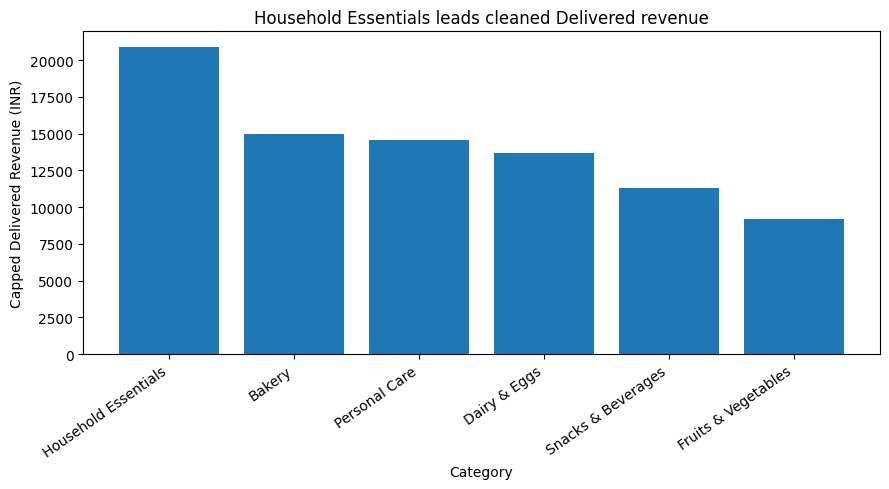

In [4]:
plt.figure(figsize=(9,5))
plt.bar(category_revenue["category"], category_revenue["delivered_revenue"])
plt.title("Household Essentials leads cleaned Delivered revenue")
plt.xlabel("Category")
plt.ylabel("Capped Delivered Revenue (INR)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Chart 2 — Monthly delivered revenue

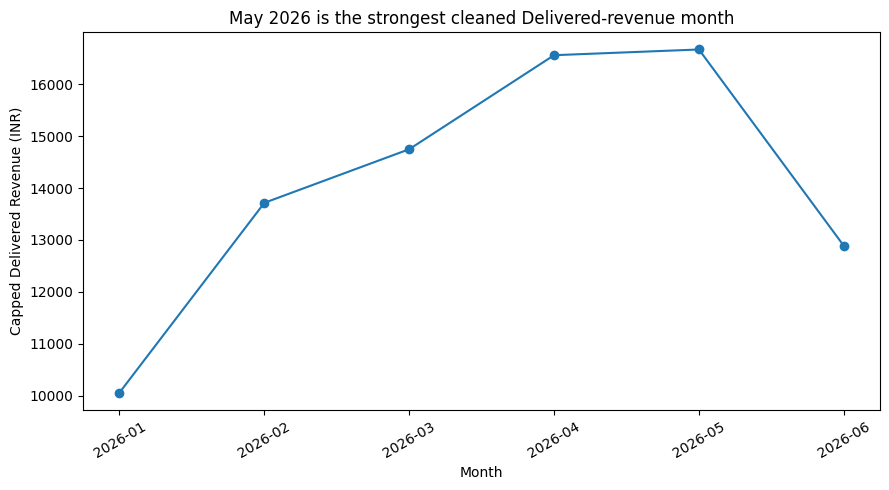

In [5]:
monthly_revenue = delivered.groupby("month", as_index=False)["amount_capped"].sum().rename(columns={"amount_capped":"delivered_revenue"})
plt.figure(figsize=(9,5))
plt.plot(monthly_revenue["month"], monthly_revenue["delivered_revenue"], marker="o")
plt.title("May 2026 is the strongest cleaned Delivered-revenue month")
plt.xlabel("Month")
plt.ylabel("Capped Delivered Revenue (INR)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Chart 3 — Supplier revenue

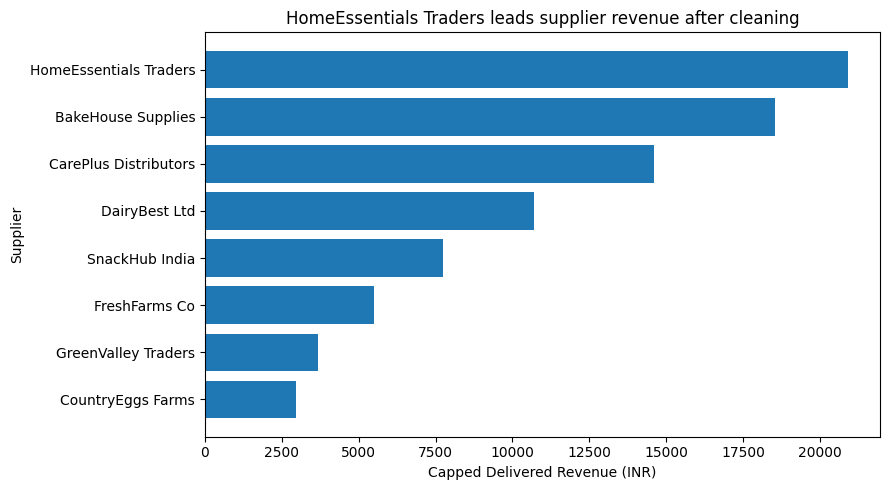

In [6]:
supplier_chart = supplier_revenue.head(8)
plt.figure(figsize=(9,5))
plt.barh(supplier_chart["supplier"][::-1], supplier_chart["delivered_revenue"][::-1])
plt.title("HomeEssentials Traders leads supplier revenue after cleaning")
plt.xlabel("Capped Delivered Revenue (INR)")
plt.ylabel("Supplier")
plt.tight_layout()
plt.show()


## Exactly 3 insights

### Insight 1 — Category leadership
**What:** Household Essentials remains the top category after cleaning and IQR capping, with ₹20,910 capped Delivered revenue.

**Why it matters:** The result matches the top category from Part 1's clean SQL diagnostic, showing that the independent Pandas workflow points to the same category despite the messy raw export.

**Next step:** Protect availability of the strongest Household Essentials products and use that category as the benchmark when reviewing weaker categories.

### Insight 2 — Supplier concentration
**What:** HomeEssentials Traders is the highest-revenue supplier in the cleaned/capped Pandas analysis at ₹20,910.

**Why it matters:** The same supplier/category combination drives the strongest cleaned revenue, so supplier performance is closely tied to the category leader.

**Next step:** Review HomeEssentials Traders' stock availability and product-level contribution before changing the category assortment.

### Insight 3 — Monthly pattern
**What:** May 2026 is the strongest cleaned Delivered-revenue month at ₹16,558.50, while January is the weakest at ₹10,059.50.

**Why it matters:** Revenue is not evenly distributed across the six-month period, so monthly planning should account for meaningful swings.

**Next step:** Compare May's product mix and order volume with January's before setting future monthly targets.
